### 👩‍💻 Fase 2: Análisis Estadístico

In [2]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

# Librerías de visualización
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

In [30]:
# Importamos el dataframe

df = pd.read_csv("files/vuelos_clientes.csv")
df.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8
1,100102,2017,1,10,4,14,2030,203.0,0,0,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3
2,100140,2017,1,6,0,6,1200,120.0,0,0,British Columbia,Dawson Creek,U5I 4F1,Female,College,73455.0,Divorced,Nova,2838.07,Standard,2016,7
3,100214,2017,1,0,0,0,0,0.0,0,0,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8
4,100272,2017,1,0,0,0,0,0.0,0,0,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1


### 🔣Análisis de variables numéricas:

In [31]:
# 1. Obtenemos el describe básico
estadisticos = round(df.describe(),2)
# 2. Calculamos la moda (Pandas devuelve un DF, por eso usamos .iloc[0])
moda = df[estadisticos.columns].mode().iloc[0:1]
moda.index = ['mode']

In [32]:
# 3. Añadimos la fila de la moda al describe
reporte_num = pd.concat([estadisticos, moda])


display(reporte_num)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Salary,CLV,Enrollment Year,Enrollment Month
count,405144.0,405144.0,405144.00,405144.00,405144.00,405144.00,405144.00,405144.00,405144.00,405144.00,405144.00,405144.00,405144.00,405144.00
mean,550134.2,2017.5,6.50,4.12,1.03,5.15,1209.09,123.71,30.71,2.49,77931.50,7989.69,2015.25,6.67
std,258934.5,0.5,3.45,5.23,2.08,6.52,1433.13,146.60,125.51,10.15,30107.66,6858.02,1.98,3.40
min,100018.0,2017.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,15609.00,1898.01,2012.00,1.00
25%,326988.0,2017.0,3.75,0.00,0.00,0.00,0.00,0.00,0.00,0.00,63970.00,3985.32,2014.00,4.00
50%,551055.0,2017.5,6.50,1.00,0.00,1.00,490.00,50.00,0.00,0.00,73455.00,5775.52,2015.00,7.00
75%,772362.0,2018.0,9.25,8.00,1.00,10.00,2337.00,239.00,0.00,0.00,82969.00,8936.37,2017.00,10.00
max,999986.0,2018.0,12.00,21.00,11.00,32.00,6293.00,676.50,876.00,71.00,407228.00,83325.38,2018.00,12.00
mode,678205.0,2017.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,73455.00,3873.65,2018.00,5.00


### Las variables numericas mas relevantes y Estadísticas descriptivas (media, mediana, moda, desviación estándar, etc.) de las variables numéricas relevantes

* **Flights Booked**: La media de vuelos reservados por cliente son 4, pero hay una gran desviacion, y la mediana esta alrededor de 1 vuelo reservado, lo que implica que hay muchos datos hacia la derecha de la distribucion, con hasta 12 vuelos reservados.
* **Flights with Companions**: la mayoria de los clientes vuelan solos, pero hay un pequeño grupo en el 75% de los datos que pueden llevar hasta 11 personas mas. 
* **Total Flights**: similar a vuelos reservados, la diferencia entre 6 vuelos de media y un vuelo de mediana muestra una distribución de los datos hasta la derecha, dado que el rango va hasta 32, se infiere que hay outliers que modifican la media. 
* **Distance**: la media son 1200 millas aproximadamente, pero la mediana esta alrededor de 488 millas, lo que implica que la mayoria de los vuelos son de corta o media distancia. 
* **Points Accumulated**: La mediana son 50 puntos, pero el rango va de cero a 676, lo que implica que hay una gran dispersion en el 50% superior de los datos
* **Points Redeemed**: Es interesante que el 75% de los valores no tienen puntos redimidos o canjeados, solo el 25% superior ha canjeado puntos, con un maximo de 876
* **Dollar Cost Points Redeemed**: esta columna esta vinculada con la anteror pero nos aporta que el número de puntos en dólares es de 71 CAD
* **Salary**: Esta columna la hemos corregido para que elimine los valores negativos, lo cual hace que la media y la mediana no estén tan separadas, 77,931 versus 73,455. Los valores estan distribuidos de manera más homogenea que las anterioresm aunque hay un pequeño grupo que tiene un salario muy alto, como es de esperable en este tipo de análisis. 
* **CLV**: Esta variable tiene una media de 7989, pero con una gran dispersión, dado que el 75% de los datos estan por debajo de 9000, y luego ese último tramo incrementa de forma abrupta hasta más de 83000.

Procedemos a escoger estas variables para visualizar rapidamente sus valores atípicos. 

A nivel anecdótico, podemos decir que el año donde mayor actividad hubo fue 2017, el que más clientes trajo fue 2018 y el mes que más actividad hay es mayo.

In [33]:
# Creamos la lista de columnas que queremos visualizar
cols_analisis = [
    'Flights Booked', 'Flights with Companions', 'Total Flights', 
    'Distance', 'Points Accumulated', 'Points Redeemed', 
    'Salary', 'CLV'
]

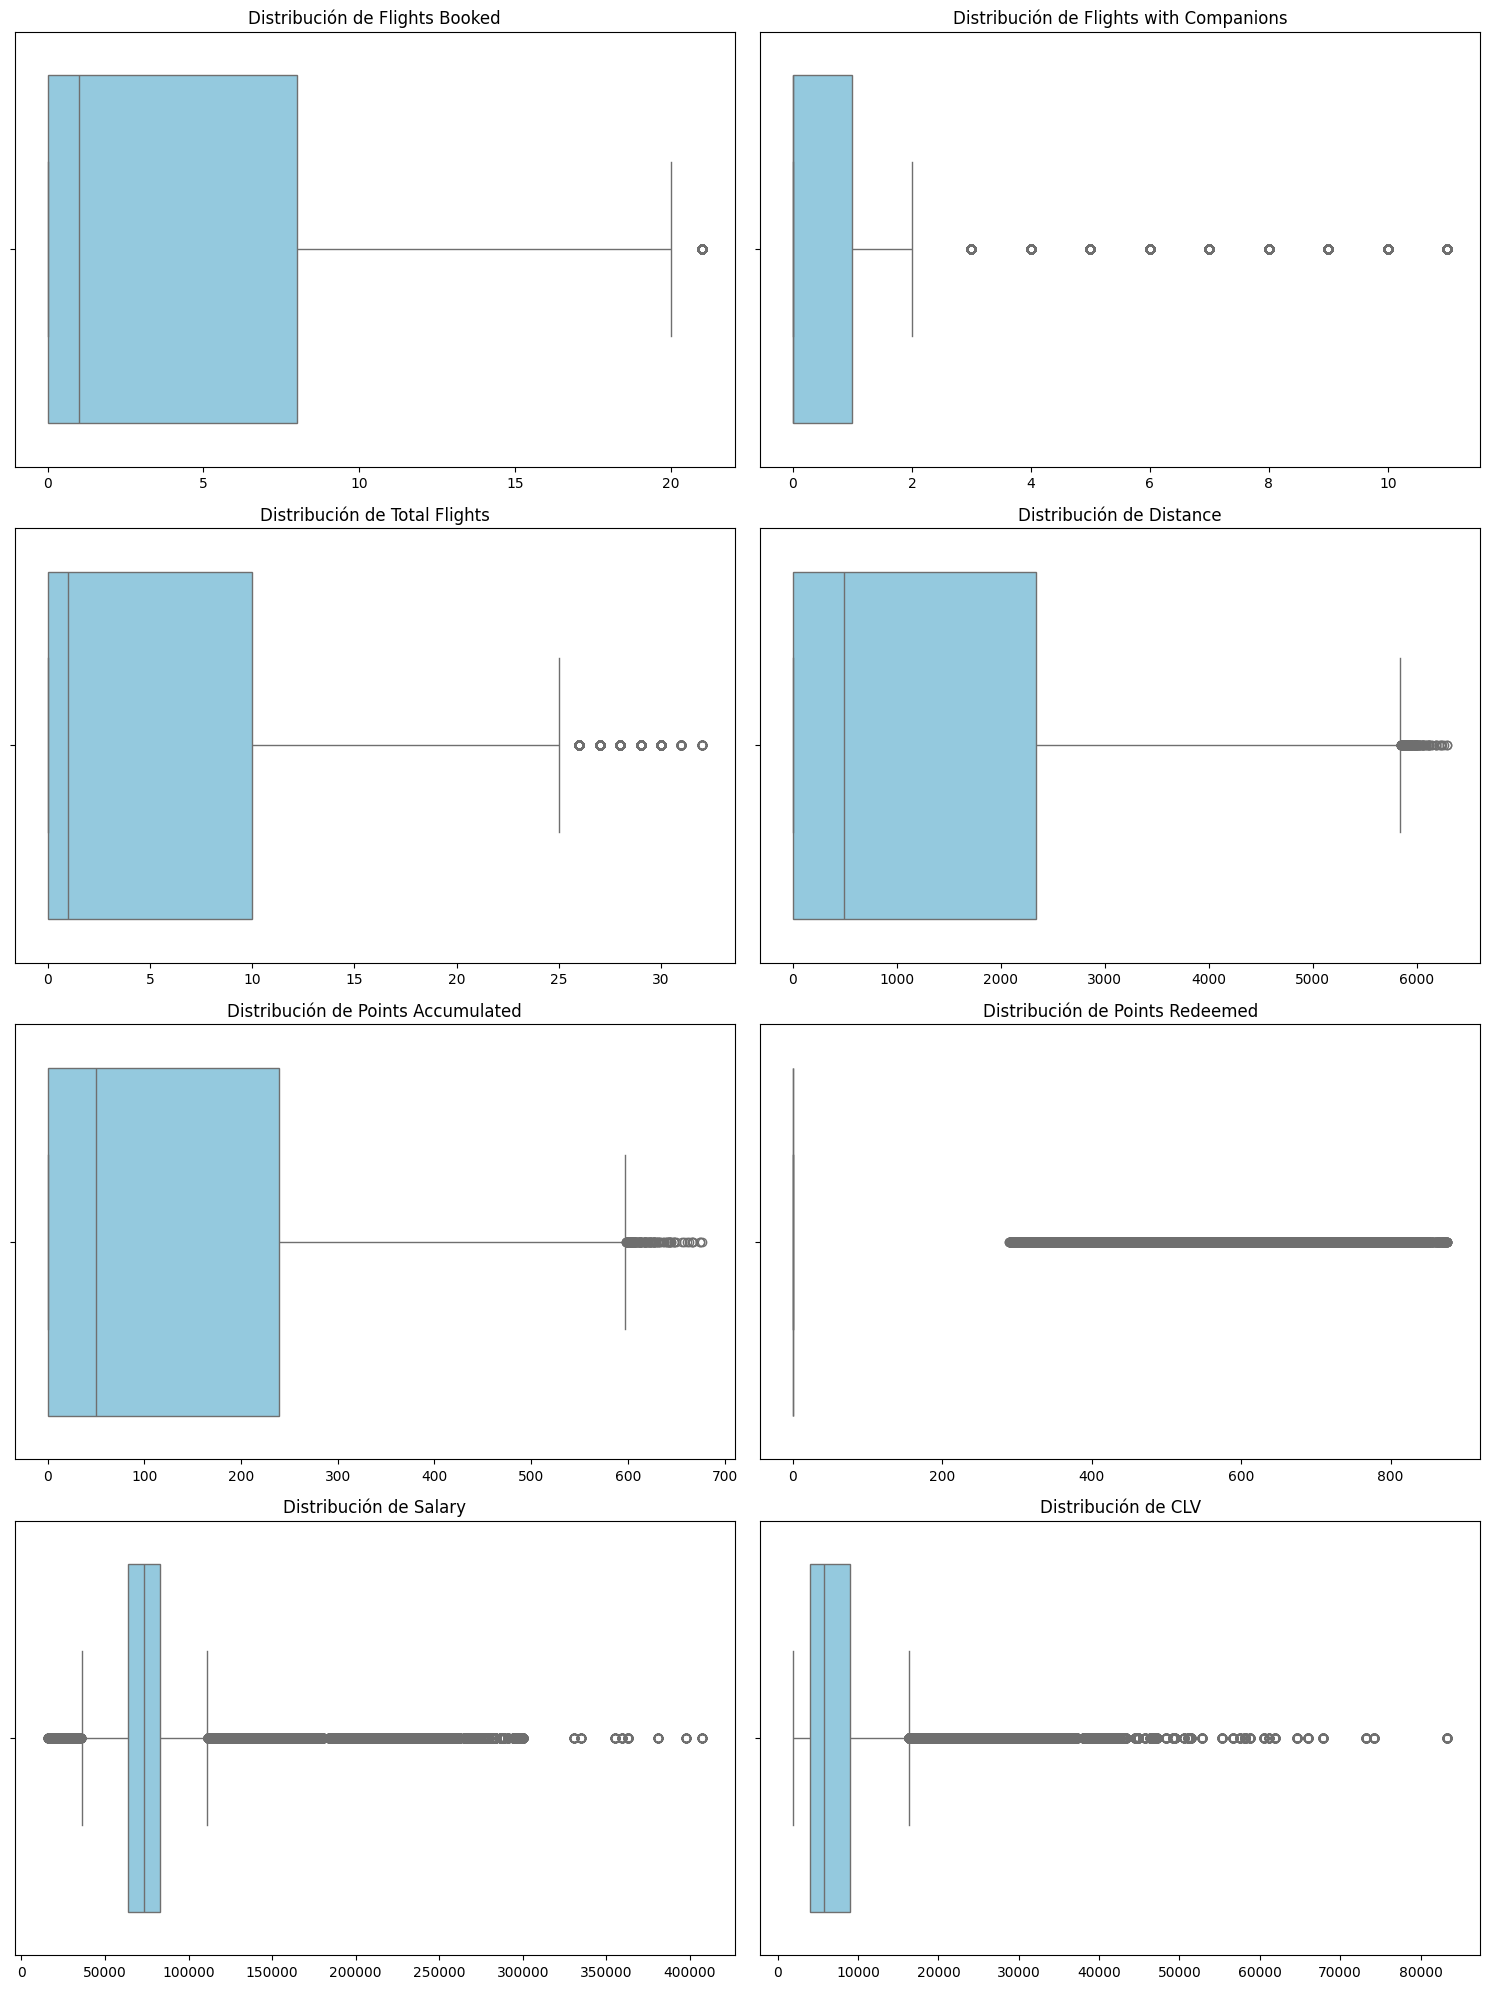

In [34]:
# Configuramos el tamaño de la figura completa
plt.figure(figsize=(15, 20))

# Bucle para crear cada subgráfico
for i, col in enumerate(cols_analisis):
    plt.subplot(4, 2, i + 1) # (filas, columnas, índice actual)
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f'Distribución de {col}')
    plt.xlabel('') # Quitamos el nombre del eje para que no se amontone

# Ajustamos el espacio entre gráficas para que no se solapen los títulos
plt.tight_layout()
plt.show()

###  Identificación de valores atípicos en las variables numéricas

Como se puede evidenciar en los boxplot anteriores, en general los datos se distribuyen hacia el límite inferior, es decir que la gente reserva pocos vuelos, con pocas personas, tienen un salario moderado, y una relación de fidelidad conservada, pero hay un segmento que sería VIP que tiene un salario mucho más elevado y consume muchos más vuelos que la media y la mediana, que por la distancia de la desviación típica serían outliers. 
En la comparación con las variables categóricas entenderemos mejor como se comportan. 

### 🔠Análisis de variables categóricas


In [35]:
df.describe(include=str)

,Province,City,Postal Code,Gender,Education,Marital Status,Loyalty Card,Enrollment Type
count,405144,405144,405144,405144,405144,405144,405144,405144
unique,11,29,55,2,5,3,3,2
top,Ontario,Toronto,V6E 3D9,Female,Bachelor,Married,Star,Standard
freq,130776,81024,21984,203400,253296,235440,184032,382200


In [36]:
lista_categoricas = ['Province', 'City', 'Gender', 'Education', 'Marital Status', 'Loyalty Card', 'Enrollment Type']

In [37]:
#Hacemos un Bucle for para ver las variables en detalle
for columna in lista_categoricas:
    print(f"--- Análisis de la columna: {columna} ---")
    print(df[columna].value_counts())

--- Análisis de la columna: Province ---
Province
Ontario                 130776
British Columbia        106728
Quebec                   79824
Alberta                  23400
Manitoba                 15984
New Brunswick            15432
Nova Scotia              12576
Saskatchewan              9912
Newfoundland              6264
Yukon                     2664
Prince Edward Island      1584
Name: count, dtype: int64
--- Análisis de la columna: City ---
City
Toronto           81024
Vancouver         62472
Montreal          49872
Winnipeg          15984
Whistler          14040
Halifax           12576
Ottawa            12312
Edmonton          11808
Trenton           11736
Quebec City       11712
Dawson Creek      10752
Fredericton       10344
Regina             9912
Kingston           9720
Tremblant          9576
Victoria           9480
Hull               8664
West Vancouver     7848
St. John's         6264
Thunder Bay        6264
Sudbury            5496
Moncton            5088
Calgary      

### 🔠 Distribución de frecuencias de las variables categóricas relevantes.

* **Province**: Tiene 11 valores unicos, siendo el más frecuente la provincia de Ontario.
* **City**: La ciudad que más se repite es Toronto, de una lista de 29 valores únicos.
* **Postal Code**: El codigo postal más relevante es V6E 3D9, correspondiente a Vancouver, British Columbia, Canada.
* **Gender**: Hay mas mujeres en los valores pero la distribución es bastante similar.
* **Education**: el nivel de formación más frecuente es 
* **Marital Status**: La gran mayoria de los casos son de personas casadas, menos de la mitad son solteras y los divorciados en menor proporción.
* **Loyalty Card**: El valor más frecuente es Star.
* **Enrollment Type**: la mayoria de ellos son standard, con la excepción de una promoción de 2018 que trajo casi 23.000 casos. 


### Análisis de correlación 

In [38]:
df_corr_numerica = df[[ 'Flights Booked', 'Flights with Companions', 'Total Flights', 
    'Distance', 'Points Accumulated', 'Points Redeemed', 'Enrollment Year',
    'Salary', 'CLV']].corr()
df_corr_numerica

,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Enrollment Year,Salary,CLV
Flights Booked,1.000000,0.502503,0.961339,0.767395,0.760213,0.188243,-0.153594,0.004358,-0.002865
Flights with Companions,0.502503,1.000000,0.721152,0.517970,0.511084,0.334399,-0.096993,0.001370,-0.002482
Total Flights,0.961339,0.721152,1.000000,0.779881,0.771933,0.257344,-0.153966,0.003928,-0.003087
Distance,0.767395,0.517970,0.779881,1.000000,0.994562,0.224281,-0.165348,0.006251,-0.004125
Points Accumulated,0.760213,0.511084,0.771933,0.994562,1.000000,0.223248,-0.164728,0.006146,-0.000935
Points Redeemed,0.188243,0.334399,0.257344,0.224281,0.223248,1.000000,-0.047799,0.001834,-0.000347
Enrollment Year,-0.153594,-0.096993,-0.153966,-0.165348,-0.164728,-0.047799,1.000000,-0.028860,-0.002159
Salary,0.004358,0.001370,0.003928,0.006251,0.006146,0.001834,-0.028860,1.000000,-0.015924
CLV,-0.002865,-0.002482,-0.003087,-0.004125,-0.000935,-0.000347,-0.002159,-0.015924,1.000000


Correlaciones Positivas
Hay correlaciones altas y positivas entre variables que posiblemente tengan relación, como Flights Booked, Total Flights, Distance, Points Accumulated, lo que nos hacen concluir que ellas aumentan de manera vinculada, a mayores bookings, mas puntos acumulan, mas distancia recorren, etc. 

Se pueden onservar correlaciones positivas y moderadas entre puntos y vuelos con acompañantes, de modo que la gente que lleva más acompañantes, tienden a ganar más puntos. 

Los puntos canjeados parecen no tener mucha correlacion con los acumulados, esta variable se relaciona más con cuantos acompañantes se llevan, y vuelos totales. 

Salario tiene correlaciones muy bajas con el resto de las variables, de modo que no se puede hacer ninguna inferencia


Correlaciones Negativas
Las correlaciones con CLV son negativas, y muy bajas. Pareciera ser que a medida que lo demás sube, el CLV baja. 

In [39]:
reporte_tarjetas = df.groupby('Loyalty Card')[['Salary', 'CLV', 'Total Flights', 'Enrollment Year']].agg(['mean', 'median'])

display(reporte_tarjetas)

Salary                    CLV           Total Flights  \
                      mean   median          mean    median          mean   
Loyalty Card                                                                
Aurora        77666.148711  73455.0  10667.986287  8114.185      5.148890   
Nova          77767.993011  73455.0   8047.008808  5790.460      5.133329   
Star          78174.303860  73455.0   6727.922021  4784.595      5.157733   

                    Enrollment Year          
             median            mean  median  
Loyalty Card                                 
Aurora          1.0     2015.240115  2015.0  
Nova            1.0     2015.261052  2015.0  
Star            1.0     2015.244653  2015.0

La unica relacion que vemos evidente con CLV es que parece ser mayor dependiendo de la Loyalty Card, siendo Aurora la clase mayor, seguida de Nova y Star, y que de media, los Aurora vuelan mas que el resto de los grupos. 

Antes de terminar, queremos analizar y agrupar por Loyalty number para ver los que mas vuelos han tenido en el df. 



In [47]:

# 1. Agrupamos por el ID del cliente y sumamos sus vuelos
# 2. Ordenamos de mayor a menor (ascending=False)
# 3. Nos quedamos con los 10 primeros (.head(10))

df_top_10 = df.groupby('Loyalty Number')['Total Flights'].sum().sort_values(ascending=False).head(10)

# Lo convertimos a DataFrame para que se vea bonito
df_top_10 = df_top_10.reset_index()

display(df_top_10)

,Loyalty Number,Total Flights
0,336882,448
1,775768,400
2,464187,399
3,255836,395
4,512296,392
5,736504,383
6,279419,379
7,215508,375
8,615561,372
9,876062,372


Es evidente que, aunque la mayoria de los loyalty numbers estan vinculados a menos de diez vuelos, los 10 primeros han tenido cientos de vuelos, lo que son circunstancias extraordinarias comparadas con el consumidor normal.  


Con estos insights terminamos la fase de Analisis Descriptivo y comenzaremos a ver la relacion entre las variables. 